# Used Laptop Price Prediction
**Machine Learning AoL — Group Members:**
- 2802392816 - Billie Godwin
- 2802393030 - Demetrius Denzell Tan
- 2802394456 - Ariya Saddhana Lius

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from datetime import datetime

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_SEED = 42
DATA_PATH = 'laptops_clean.csv'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print('All imports successful.')
print(f'scikit-learn version: {__import__("sklearn").__version__}')


All imports successful.
scikit-learn version: 1.8.0


## 2. Data Loading & Initial Inspection

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(10)


Shape: (156, 19)


,name,brand,price_idr,cpu_brand,cpu_gen,cpu_tier,cpu_model,ram_gb,ssd_gb,storage_type,nvme,screen_inch,resolution,display_type,touchscreen,gpu_type,os,sold_count,rating
0,Cuci Gudang DELL LATITUDE e5420 / Corei5 / 4GB...,Dell,3350000,Intel,NaN,i5,NaN,4,NaN,SSD,0,NaN,HD,NaN,0,Integrated,NaN,4.0,4.5
1,Cuci Gudang Laptop Bekas Lenovo x240 Core i5 4...,Lenovo,2850000,Intel,4.0,i5,4300U,8,128.0,SSD,0,NaN,HD,NaN,0,Integrated,NaN,100.0,4.9
2,Cuci Gudang Laptop Bekas Toshiba R30 Corei5 42...,Toshiba,1699000,Intel,4.0,i5,4210M,4,320.0,HDD,0,13.3,HD,NaN,0,Integrated,Windows 8,50.0,4.6
3,Cuci Gudang Laptop Dell D630 Core2Duo - 2GB - ...,Dell,1499000,Intel,NaN,core2duo,NaN,2,NaN,SSD,0,NaN,NaN,NaN,0,Integrated,NaN,1.0,NaN
4,Cuci Gudang Laptop Dell E6330 Core i7 3520M 4G...,Dell,3650000,Intel,3.0,i7,3520M,4,NaN,SSD,0,13.3,HD,NaN,0,Integrated,Windows 7,17.0,4.8
5,Dell Latitude E5450 Core i5 - 16GB - SSD 256 -...,Dell,4250000,Intel,NaN,i5,NaN,16,256.0,SSD,0,14.0,HD,NaN,0,Integrated,Windows 10,11.0,5.0
6,Dell Latitude E7240 Core i5 Gen4 - 8GB - SSD 1...,Dell,3600000,Intel,4.0,i5,4310U,8,128.0,SSD,0,12.5,HD,NaN,0,Integrated,NaN,11.0,4.6
7,HP ZBook Firefly G8 i7 Gen11 14” FHD Workstati...,Hp,6900000,Intel,11.0,i7,NaN,16,256.0,SSD,0,14.0,FHD,IPS,1,Integrated,Windows 11,3.0,5.0
8,Jual Laptop Bekas Lenovo Thinkpad X230 Corei5 ...,Lenovo,2499000,Intel,3.0,i5,3320M,4,NaN,SSD,0,12.5,HD,NaN,0,Integrated,NaN,250.0,4.6
9,Laptop 2 in 1 Dell Latitude 5300 Core i7 8th G...,Dell,3650000,Intel,8.0,i7,NaN,16,256.0,SSD,1,13.3,FHD,IPS,1,Integrated,Windows 10,27.0,5.0


In [3]:
print('Data types:')
print(df.dtypes)


Data types:
name                str
brand               str
price_idr         int64
cpu_brand           str
cpu_gen         float64
cpu_tier            str
cpu_model           str
ram_gb            int64
ssd_gb          float64
storage_type        str
nvme              int64
screen_inch     float64
resolution          str
display_type        str
touchscreen       int64
gpu_type            str
os                  str
sold_count      float64
rating          float64
dtype: object


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with missing values:')
display(missing_df)


Columns with missing values:


,Missing Count,Missing %
os,95,60.9
display_type,77,49.4
screen_inch,42,26.9
cpu_model,41,26.3
cpu_gen,25,16.0
resolution,22,14.1
rating,10,6.4
ssd_gb,8,5.1
sold_count,6,3.8
cpu_tier,5,3.2


In [5]:
display(df.describe(include='all').T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,156,156,Cuci Gudang DELL LATITUDE e5420 / Corei5 / 4GB...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,156,6,Lenovo,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_idr,156.0,NaN,NaN,NaN,4615575.641026,2207023.677216,990000.0,3086750.0,3974500.0,5687250.0,14000000.0
cpu_brand,151,2,Intel,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cpu_gen,131.0,NaN,NaN,NaN,6.183206,2.517024,2.0,4.0,6.0,8.0,12.0
cpu_tier,151,9,i5,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cpu_model,115,53,5300U,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ram_gb,156.0,NaN,NaN,NaN,10.974359,6.840061,2.0,8.0,8.0,16.0,32.0
ssd_gb,148.0,NaN,NaN,NaN,255.148649,104.128411,128.0,225.0,256.0,256.0,512.0
storage_type,156,2,SSD,139,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploratory Data Analysis

### 3.1 Price Distribution

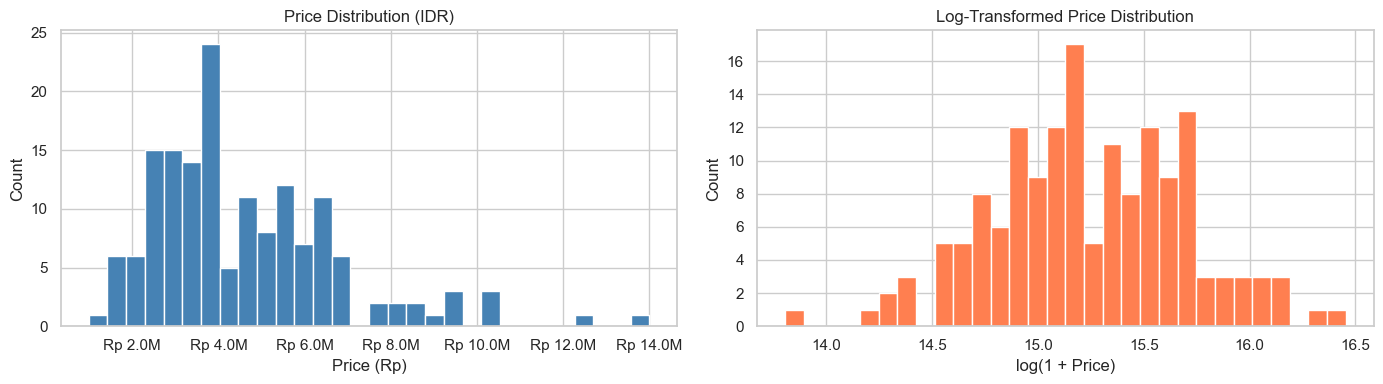

Price range: Rp 990,000 - Rp 14,000,000
Median price: Rp 3,974,500
Mean price:   Rp 4,615,576


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['price_idr'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (IDR)')
axes[0].set_xlabel('Price (Rp)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}M'))

axes[1].hist(np.log1p(df['price_idr']), bins=30, color='coral', edgecolor='white')
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Price range: Rp {df['price_idr'].min():,.0f} - Rp {df['price_idr'].max():,.0f}")
print(f"Median price: Rp {df['price_idr'].median():,.0f}")
print(f"Mean price:   Rp {df['price_idr'].mean():,.0f}")


### 3.2 Price by Key Categorical Features

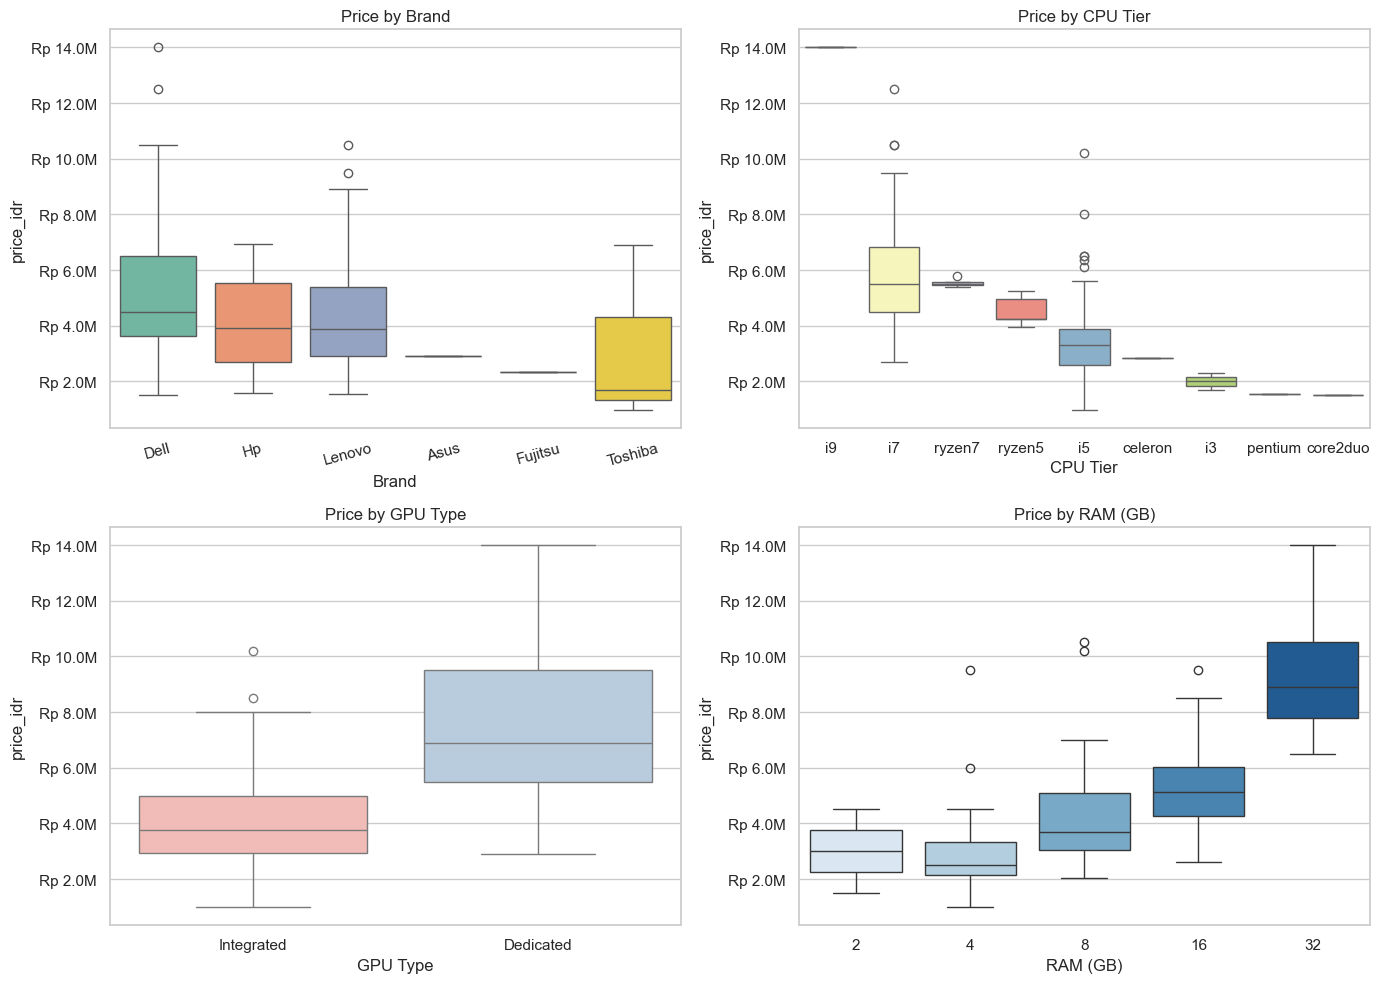

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Brand
order_brand = df.groupby('brand')['price_idr'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='brand', y='price_idr', order=order_brand, ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Price by Brand')
axes[0,0].set_xlabel('Brand')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}M'))
axes[0,0].tick_params(axis='x', rotation=15)

# CPU Tier
order_cpu = df.groupby('cpu_tier')['price_idr'].median().sort_values(ascending=False).index
sns.boxplot(data=df[df['cpu_tier'].notna()], x='cpu_tier', y='price_idr', order=order_cpu, ax=axes[0,1], palette='Set3')
axes[0,1].set_title('Price by CPU Tier')
axes[0,1].set_xlabel('CPU Tier')
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}M'))

# GPU Type
sns.boxplot(data=df, x='gpu_type', y='price_idr', ax=axes[1,0], palette='Pastel1')
axes[1,0].set_title('Price by GPU Type')
axes[1,0].set_xlabel('GPU Type')
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}M'))

# RAM
order_ram = sorted(df['ram_gb'].dropna().unique())
sns.boxplot(data=df[df['ram_gb'].notna()], x='ram_gb', y='price_idr', order=order_ram, ax=axes[1,1], palette='Blues')
axes[1,1].set_title('Price by RAM (GB)')
axes[1,1].set_xlabel('RAM (GB)')
axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}M'))

plt.tight_layout()
plt.show()


### 3.3 Price vs Numeric Features

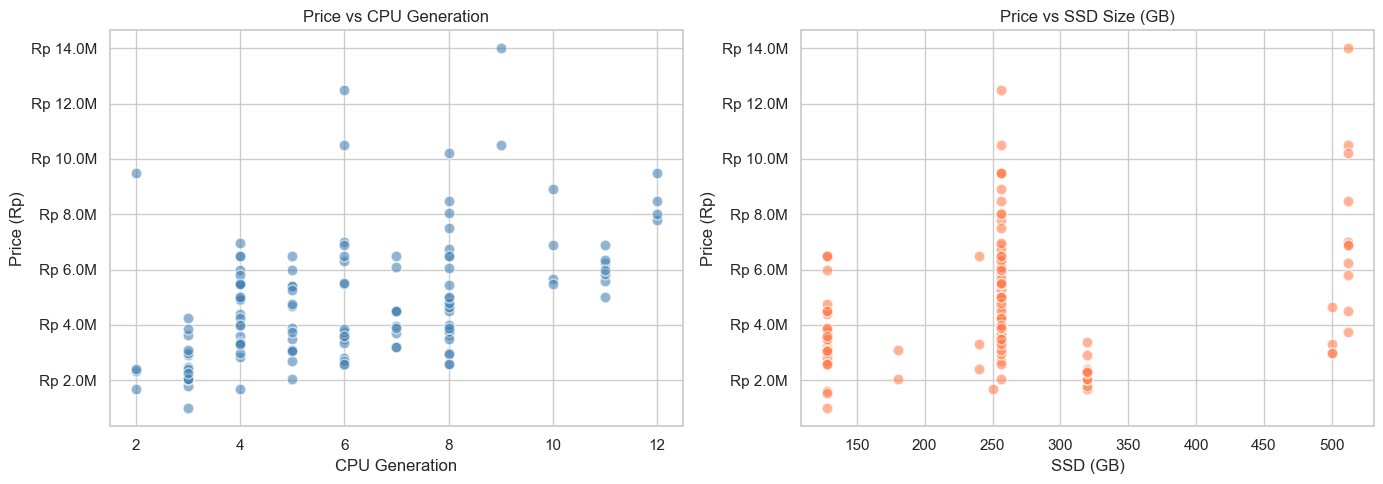

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CPU Generation
cpu_gen_data = df[df['cpu_gen'].notna()]
axes[0].scatter(cpu_gen_data['cpu_gen'], cpu_gen_data['price_idr'], alpha=0.6, color='steelblue', edgecolors='white', s=60)
axes[0].set_title('Price vs CPU Generation')
axes[0].set_xlabel('CPU Generation')
axes[0].set_ylabel('Price (Rp)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}M'))

# SSD Size
ssd_data = df[df['ssd_gb'].notna() & (df['ssd_gb'] > 16)]
axes[1].scatter(ssd_data['ssd_gb'], ssd_data['price_idr'], alpha=0.6, color='coral', edgecolors='white', s=60)
axes[1].set_title('Price vs SSD Size (GB)')
axes[1].set_xlabel('SSD (GB)')
axes[1].set_ylabel('Price (Rp)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}M'))

plt.tight_layout()
plt.show()


### 3.4 Correlation Heatmap

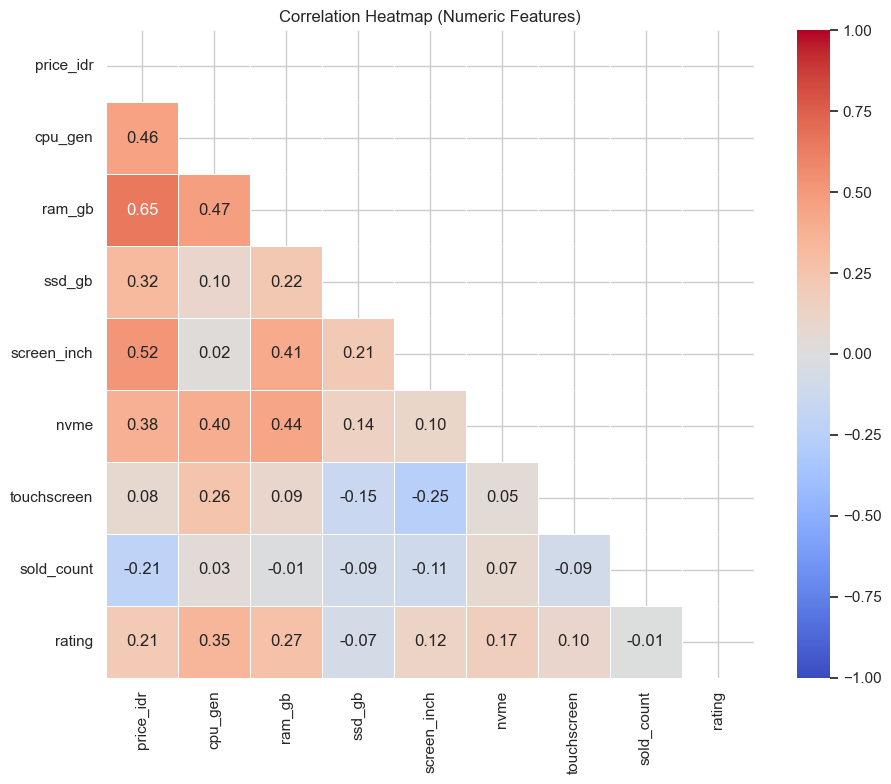

In [9]:
numeric_cols = ['price_idr', 'cpu_gen', 'ram_gb', 'ssd_gb', 'screen_inch',
                'nvme', 'touchscreen', 'sold_count', 'rating']
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()


### 3.5 Sold Count & Rating Distributions

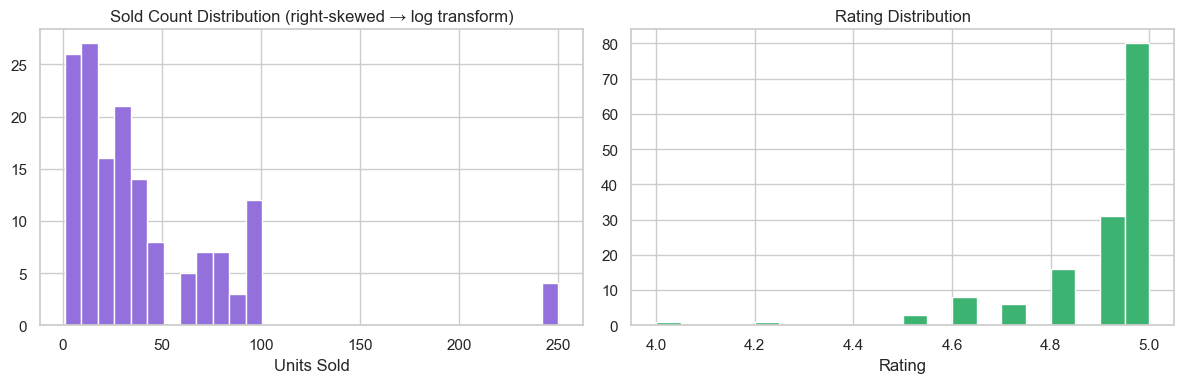

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sold = df['sold_count'].dropna()
axes[0].hist(sold, bins=30, color='mediumpurple', edgecolor='white')
axes[0].set_title('Sold Count Distribution (right-skewed → log transform)')
axes[0].set_xlabel('Units Sold')

rating = df['rating'].dropna()
axes[1].hist(rating, bins=20, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Rating Distribution')
axes[1].set_xlabel('Rating')

plt.tight_layout()
plt.show()


## 4. Preprocessing & Feature Engineering

In [11]:
# Work on a copy
data = df.copy()

# Drop columns not useful for modeling
data.drop(columns=['name', 'cpu_model', 'cpu_brand'], inplace=True)
print('Dropped: name, cpu_model, cpu_brand')

# Fix ssd_gb anomalies (values <= 16 are data artifacts)
anomaly_mask = data['ssd_gb'] <= 16
print(f'SSD anomalies (<=16 GB) set to NaN: {anomaly_mask.sum()} rows')
data.loc[anomaly_mask, 'ssd_gb'] = np.nan

# Ensure numeric types
numeric_fields = ['cpu_gen', 'ram_gb', 'ssd_gb', 'screen_inch',
                  'nvme', 'touchscreen', 'sold_count', 'rating']
for col in numeric_fields:
    data[col] = pd.to_numeric(data[col], errors='coerce')

print('Numeric dtypes enforced.')


Dropped: name, cpu_model, cpu_brand
SSD anomalies (<=16 GB) set to NaN: 0 rows
Numeric dtypes enforced.


In [12]:
# Binary feature: is_ips
data['is_ips'] = (data['display_type'] == 'IPS').astype(int)
data.drop(columns=['display_type'], inplace=True)

# Binary feature: has_os_label (proxy for listing completeness)
data['has_os_label'] = data['os'].notna().astype(int)
data.drop(columns=['os'], inplace=True)

# Binary feature: is_fhd (missing → 0, assume HD)
data['is_fhd'] = (data['resolution'] == 'FHD').astype(int)
data.drop(columns=['resolution'], inplace=True)

# Binary: storage_type (SSD=1, HDD=0)
data['storage_type_bin'] = (data['storage_type'] == 'SSD').astype(int)
data.drop(columns=['storage_type'], inplace=True)

# Binary: gpu_type (Dedicated=1, Integrated=0)
data['gpu_type_bin'] = (data['gpu_type'] == 'Dedicated').astype(int)
data.drop(columns=['gpu_type'], inplace=True)

# Log transform sold_count
data['sold_count_log'] = np.log1p(data['sold_count'])
data.drop(columns=['sold_count'], inplace=True)

# Group rare cpu_tier values
tier_map = {'core2duo': 'other', 'i9': 'i7', 'ryzen5': 'ryzen', 'ryzen7': 'ryzen'}
data['cpu_tier'] = data['cpu_tier'].replace(tier_map)
print('CPU tier value counts after grouping:')
print(data['cpu_tier'].value_counts())


CPU tier value counts after grouping:
cpu_tier
i5         71
i7         64
ryzen      11
i3          2
other       1
celeron     1
pentium     1
Name: count, dtype: int64


In [13]:
# Final feature set
print('Final columns:', data.columns.tolist())
print(f'Shape: {data.shape}')
print()
missing_final = data.isnull().sum()
print('Remaining missing values:')
print(missing_final[missing_final > 0])


Final columns: ['brand', 'price_idr', 'cpu_gen', 'cpu_tier', 'ram_gb', 'ssd_gb', 'nvme', 'screen_inch', 'touchscreen', 'rating', 'is_ips', 'has_os_label', 'is_fhd', 'storage_type_bin', 'gpu_type_bin', 'sold_count_log']
Shape: (156, 16)

Remaining missing values:
cpu_gen           25
cpu_tier           5
ssd_gb             8
screen_inch       42
rating            10
sold_count_log     6
dtype: int64


## 5. Train/Test Split

In [14]:
X = data.drop(columns=['price_idr'])
y = data['price_idr']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f'Training set:   {X_train.shape[0]} rows')
print(f'Test set:       {X_test.shape[0]} rows')
print(f'Features:       {X_train.shape[1]} columns')
print(f'\nFeature names: {X_train.columns.tolist()}')


Training set:   124 rows
Test set:       32 rows
Features:       15 columns

Feature names: ['brand', 'cpu_gen', 'cpu_tier', 'ram_gb', 'ssd_gb', 'nvme', 'screen_inch', 'touchscreen', 'rating', 'is_ips', 'has_os_label', 'is_fhd', 'storage_type_bin', 'gpu_type_bin', 'sold_count_log']


## 6. Preprocessing Pipeline

In [15]:
# Separate column types
numerical_cols = ['cpu_gen', 'ram_gb', 'ssd_gb', 'screen_inch',
                  'nvme', 'touchscreen', 'is_ips', 'has_os_label',
                  'is_fhd', 'storage_type_bin', 'gpu_type_bin',
                  'sold_count_log', 'rating']

categorical_cols = ['brand', 'cpu_tier']

# Verify all columns are accounted for
all_cols = numerical_cols + categorical_cols
missing_cols = [c for c in X_train.columns if c not in all_cols]
extra_cols = [c for c in all_cols if c not in X_train.columns]
print('Unaccounted columns:', missing_cols)
print('Missing from data:', extra_cols)

# Build shared preprocessor
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols),
])

# Fit only on training data (no leakage)
preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
print(f'\nTransformed training shape: {X_train_transformed.shape}')
print('Preprocessing pipeline fitted on training data only.')


Unaccounted columns: []
Missing from data: []

Transformed training shape: (124, 24)
Preprocessing pipeline fitted on training data only.


## 7. Model Training

### 7.1 Linear Regression (Baseline)

In [16]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression()),
])
lr_pipeline.fit(X_train, y_train)
print('Linear Regression trained.')


Linear Regression trained.


### 7.2 Random Forest Regression

In [17]:
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_leaf': [1, 2, 4],
}

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_SEED)),
])

rf_gs = GridSearchCV(
    rf_pipeline, rf_param_grid,
    cv=5, scoring='neg_mean_absolute_error',
    n_jobs=-1, verbose=0,
)
rf_gs.fit(X_train, y_train)

print(f'Best params: {rf_gs.best_params_}')
print(f'Best CV MAE: Rp {-rf_gs.best_score_:,.0f}')


Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
Best CV MAE: Rp 836,457


### 7.3 Support Vector Regression (SVR)

In [18]:
svr_param_grid = {
    'model__C': [1, 10, 100, 1000],
    'model__epsilon': [10000, 50000, 100000],
    'model__kernel': ['rbf', 'linear'],
}

svr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVR()),
])

svr_gs = GridSearchCV(
    svr_pipeline, svr_param_grid,
    cv=5, scoring='neg_mean_absolute_error',
    n_jobs=-1, verbose=0,
)
svr_gs.fit(X_train, y_train)

print(f'Best params: {svr_gs.best_params_}')
print(f'Best CV MAE: Rp {-svr_gs.best_score_:,.0f}')


Best params: {'model__C': 1000, 'model__epsilon': 100000, 'model__kernel': 'linear'}
Best CV MAE: Rp 1,575,054


## 8. Evaluation

In [19]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'y_pred': y_pred}

lr_result  = evaluate_model('Linear Regression (Baseline)', lr_pipeline, X_test, y_test)
rf_result  = evaluate_model('Random Forest (Tuned)',        rf_gs.best_estimator_, X_test, y_test)
svr_result = evaluate_model('SVR (Tuned)',                  svr_gs.best_estimator_, X_test, y_test)

results_list = [lr_result, rf_result, svr_result]


### 8.1 Model Comparison Table

In [20]:
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'y_pred'}
    for r in results_list
]).set_index('Model')

display_df = results_df.copy()
display_df['MAE']  = display_df['MAE'].map(lambda x: f'Rp {x:,.0f}')
display_df['RMSE'] = display_df['RMSE'].map(lambda x: f'Rp {x:,.0f}')
display_df['R2']   = display_df['R2'].map(lambda x: f'{x:.4f}')
display_df.columns = ['MAE', 'RMSE', 'R²']
display(display_df)


,MAE,RMSE,R²
Model,,,
Linear Regression (Baseline),"Rp 1,015,295","Rp 1,353,622",0.4538
Random Forest (Tuned),"Rp 686,669","Rp 1,091,164",0.6451
SVR (Tuned),"Rp 1,222,965","Rp 1,728,616",0.1093


### 8.2 Actual vs Predicted

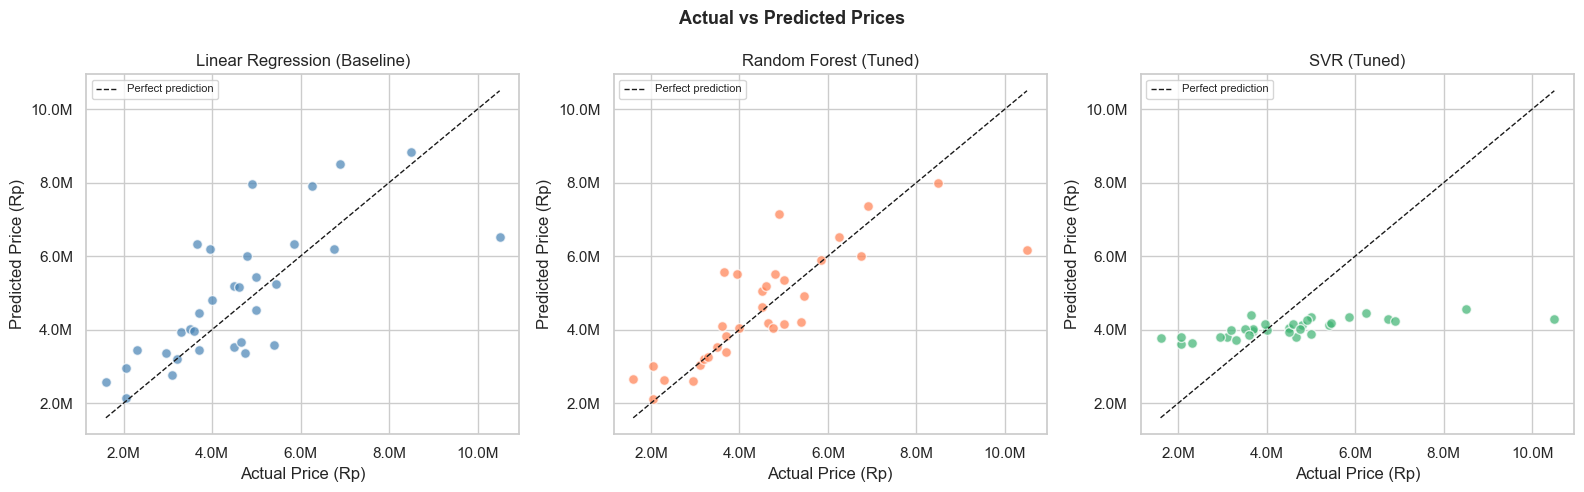

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['steelblue', 'coral', 'mediumseagreen']

for ax, result, color in zip(axes, results_list, colors):
    y_pred = result['y_pred']
    ax.scatter(y_test, y_pred, alpha=0.7, color=color, edgecolors='white', s=50)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
    ax.set_title(result['Model'])
    ax.set_xlabel('Actual Price (Rp)')
    ax.set_ylabel('Predicted Price (Rp)')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted Prices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 8.3 Residual Analysis

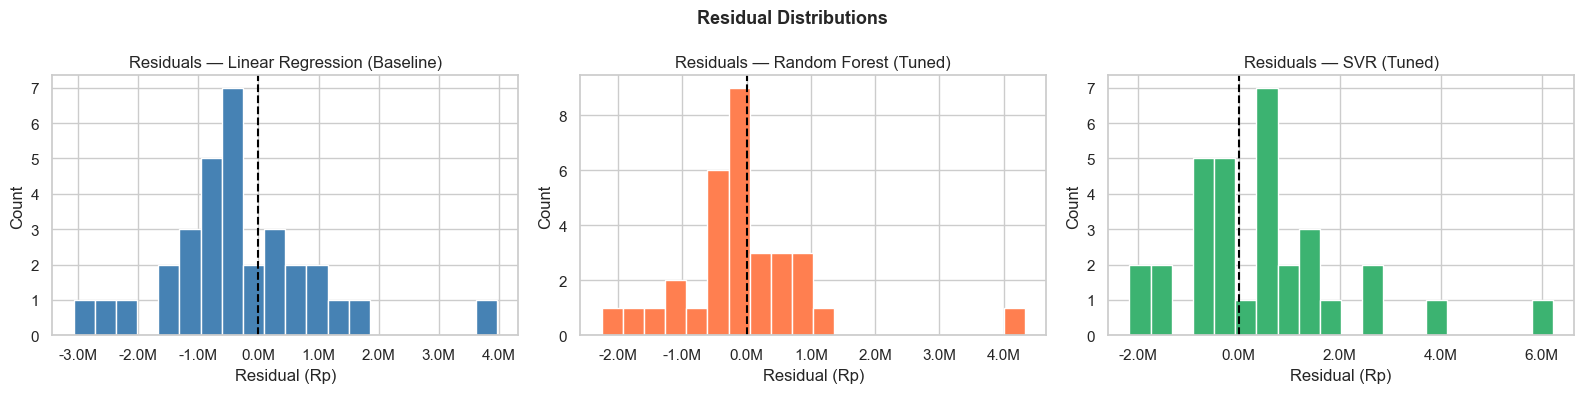

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ['steelblue', 'coral', 'mediumseagreen']

for ax, result, color in zip(axes, results_list, colors):
    residuals = y_test.values - result['y_pred']
    ax.hist(residuals, bins=20, color=color, edgecolor='white')
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_title(f'Residuals — {result["Model"]}')
    ax.set_xlabel('Residual (Rp)')
    ax.set_ylabel('Count')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle('Residual Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 8.4 Random Forest Feature Importances

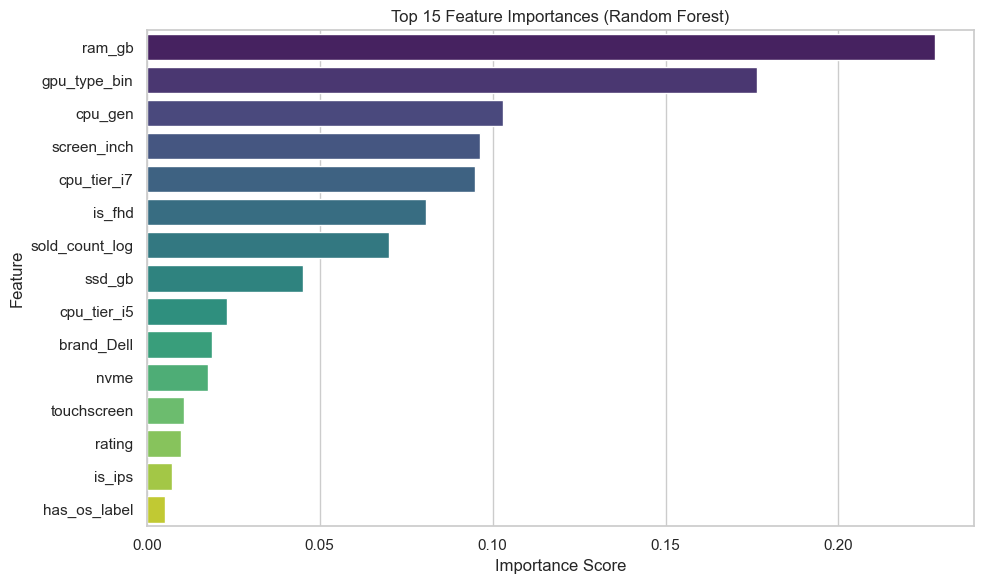

In [23]:
rf_best = rf_gs.best_estimator_

# Get feature names from preprocessor
ohe_cats = (rf_best.named_steps['preprocessor']
              .named_transformers_['cat']
              .named_steps['ohe']
              .get_feature_names_out(categorical_cols))
feature_names = numerical_cols + list(ohe_cats)

importances = rf_best.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


### 8.5 Cross-Validation Scores

In [24]:
print('Cross-validation R² scores (5-fold, full dataset):')
for name, model in [('Linear Regression', lr_pipeline),
                    ('Random Forest',     rf_gs.best_estimator_),
                    ('SVR',               svr_gs.best_estimator_)]:
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    print(f'  {name:30s}: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')


Cross-validation R² scores (5-fold, full dataset):
  Linear Regression             : 0.3558 ± 0.2808


  Random Forest                 : 0.4313 ± 0.0971
  SVR                           : -0.0966 ± 0.2398


### 8.6 Result Interpretation

In [25]:
best_result = max(results_list, key=lambda r: r['R2'])
median_price = y.median()
mae_pct = best_result['MAE'] / median_price * 100

print(f"Best model: {best_result['Model']}")
print(f"  MAE:  Rp {best_result['MAE']:,.0f} ({mae_pct:.1f}% of median price Rp {median_price:,.0f})")
print(f"  RMSE: Rp {best_result['RMSE']:,.0f}")
print(f"  R²:   {best_result['R2']:.4f}")
print()
print('Interpretation:')
print(f'  On average, the {best_result["Model"]} predicts used laptop prices')
print(f'  within Rp {best_result["MAE"]:,.0f} (~{mae_pct:.1f}%) of the actual price.')


Best model: Random Forest (Tuned)
  MAE:  Rp 686,669 (17.3% of median price Rp 3,974,500)
  RMSE: Rp 1,091,164
  R²:   0.6451

Interpretation:
  On average, the Random Forest (Tuned) predicts used laptop prices
  within Rp 686,669 (~17.3%) of the actual price.


## 9. Save Best Model

In [26]:
# Identify best model by R² on test set
model_registry = {
    'Linear Regression (Baseline)': lr_pipeline,
    'Random Forest (Tuned)':        rf_gs.best_estimator_,
    'SVR (Tuned)':                  svr_gs.best_estimator_,
}
best_name = max(results_list, key=lambda r: r['R2'])['Model']
best_pipeline = model_registry[best_name]

# Save pipeline
joblib.dump(best_pipeline, 'best_model.pkl')
print(f'Saved best_model.pkl  ({best_name})')

# Save metadata
best_r = next(r for r in results_list if r['Model'] == best_name)
if hasattr(best_pipeline, 'best_params_'):
    best_params = best_pipeline.best_params_
elif best_name == 'Random Forest (Tuned)':
    best_params = rf_gs.best_params_
elif best_name == 'SVR (Tuned)':
    best_params = svr_gs.best_params_
else:
    best_params = {}

metadata = {
    'model_type': best_name,
    'best_params': best_params,
    'feature_names': X.columns.tolist(),
    'metrics': {
        'MAE':  round(best_r['MAE'], 2),
        'RMSE': round(best_r['RMSE'], 2),
        'R2':   round(best_r['R2'], 4),
    },
    'training_date': datetime.now().strftime('%Y-%m-%d'),
    'n_train': len(X_train),
    'n_test': len(X_test),
}
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('Saved model_metadata.json')
print(json.dumps(metadata, indent=2))


Saved best_model.pkl  (Random Forest (Tuned))
Saved model_metadata.json
{
  "model_type": "Random Forest (Tuned)",
  "best_params": {
    "model__max_depth": 10,
    "model__min_samples_leaf": 2,
    "model__n_estimators": 200
  },
  "feature_names": [
    "brand",
    "cpu_gen",
    "cpu_tier",
    "ram_gb",
    "ssd_gb",
    "nvme",
    "screen_inch",
    "touchscreen",
    "rating",
    "is_ips",
    "has_os_label",
    "is_fhd",
    "storage_type_bin",
    "gpu_type_bin",
    "sold_count_log"
  ],
  "metrics": {
    "MAE": 686668.77,
    "RMSE": 1091164.43,
    "R2": 0.6451
  },
  "training_date": "2026-05-24",
  "n_train": 124,
  "n_test": 32
}


In [27]:
# Verification: reload and predict on a sample
loaded = joblib.load('best_model.pkl')
sample = X_test.iloc[[0]]
pred = loaded.predict(sample)[0]
actual = y_test.iloc[0]
print(f'Verification — Sample prediction:')
print(f'  Predicted: Rp {pred:,.0f}')
print(f'  Actual:    Rp {actual:,.0f}')
print(f'  Error:     Rp {abs(pred - actual):,.0f}')
print()
print('Model ready for Streamlit deployment.')


Verification — Sample prediction:
  Predicted: Rp 2,619,028
  Actual:    Rp 2,300,000
  Error:     Rp 319,028

Model ready for Streamlit deployment.


## 10. Backtesting — Predicted vs Actual on Test Set

The model was trained on **used laptop listings from Tokopedia**, so its predictions already reflect second-hand market prices — not new retail prices. The table below shows how well it predicts against the 32 held-out test listings it never saw during training.

In [28]:

# Backtest: predicted vs actual for all 32 test laptops
best_model = joblib.load('best_model.pkl')
y_pred_test = best_model.predict(X_test)

backtest_df = X_test.copy()
backtest_df['actual_price'] = y_test.values
backtest_df['predicted_price'] = y_pred_test.round(0)
backtest_df['error'] = backtest_df['predicted_price'] - backtest_df['actual_price']
backtest_df['abs_error'] = backtest_df['error'].abs()
backtest_df['error_pct'] = (backtest_df['error'] / backtest_df['actual_price'] * 100).round(1)

def label_accuracy(pct):
    if abs(pct) <= 10:
        return 'Great  (<10%)'
    elif abs(pct) <= 25:
        return 'OK     (10-25%)'
    else:
        return 'Wide   (>25%)'

backtest_df['accuracy'] = backtest_df['error_pct'].apply(label_accuracy)

display_cols = ['brand', 'cpu_tier', 'ram_gb', 'ssd_gb',
                'actual_price', 'predicted_price', 'error', 'error_pct', 'accuracy']
display_df = backtest_df[display_cols].copy()
display_df['actual_price']    = display_df['actual_price'].map(lambda x: f'Rp {x:,.0f}')
display_df['predicted_price'] = display_df['predicted_price'].map(lambda x: f'Rp {x:,.0f}')
display_df['error']           = display_df['error'].map(lambda x: f'Rp {x:+,.0f}')
display_df['error_pct']       = display_df['error_pct'].map(lambda x: f'{x:+.1f}%')
display_df.columns = ['Brand', 'CPU Tier', 'RAM (GB)', 'SSD (GB)',
                      'Actual Price', 'Predicted Price', 'Error (Rp)', 'Error %', 'Rating']

display_df = display_df.reset_index(drop=True)
display_df.index += 1
display(display_df)


,Brand,CPU Tier,RAM (GB),SSD (GB),Actual Price,Predicted Price,Error (Rp),Error %,Rating
1,Hp,i3,4,320.0,"Rp 2,300,000","Rp 2,619,028","Rp +319,028",+13.9%,OK (10-25%)
2,Hp,NaN,8,256.0,"Rp 3,699,000","Rp 3,384,343","Rp -314,657",-8.5%,Great (<10%)
3,Hp,i5,4,128.0,"Rp 1,599,000","Rp 2,652,658","Rp +1,053,658",+65.9%,Wide (>25%)
4,Hp,i7,8,128.0,"Rp 4,499,000","Rp 4,601,591","Rp +102,591",+2.3%,Great (<10%)
5,Lenovo,i7,8,256.0,"Rp 10,500,000","Rp 6,170,396","Rp -4,329,604",-41.2%,Wide (>25%)
6,Dell,i5,16,256.0,"Rp 3,999,000","Rp 4,049,939","Rp +50,939",+1.3%,Great (<10%)
7,Hp,i5,16,256.0,"Rp 3,950,000","Rp 5,524,395","Rp +1,574,395",+39.9%,Wide (>25%)
8,Lenovo,i5,8,128.0,"Rp 3,099,000","Rp 3,045,271","Rp -53,729",-1.7%,Great (<10%)
9,Hp,ryzen,16,256.0,"Rp 5,399,000","Rp 4,218,360","Rp -1,180,640",-21.9%,OK (10-25%)
10,Lenovo,i7,16,256.0,"Rp 4,799,000","Rp 5,500,581","Rp +701,581",+14.6%,OK (10-25%)


In [29]:

# Accuracy breakdown summary
accuracy_counts = backtest_df['accuracy'].value_counts()
print('=== Accuracy Summary (32 test laptops) ===')
for label, count in accuracy_counts.items():
    print(f'  {label}: {count} laptops ({count/len(backtest_df)*100:.0f}%)')

print()
print(f'Median absolute error : Rp {backtest_df["abs_error"].median():,.0f}')
print(f'Mean  absolute error  : Rp {backtest_df["abs_error"].mean():,.0f}')
worst = backtest_df.nlargest(3, 'abs_error')[['brand', 'cpu_tier', 'ram_gb', 'actual_price', 'predicted_price', 'error_pct']]
worst['actual_price']    = worst['actual_price'].map(lambda x: f'Rp {x:,.0f}')
worst['predicted_price'] = worst['predicted_price'].map(lambda x: f'Rp {x:,.0f}')
worst['error_pct']       = worst['error_pct'].map(lambda x: f'{x:+.1f}%')
print()
print('Top 3 worst predictions:')
display(worst.reset_index(drop=True))


=== Accuracy Summary (32 test laptops) ===
  Great  (<10%): 16 laptops (50%)
  OK     (10-25%): 10 laptops (31%)
  Wide   (>25%): 6 laptops (19%)

Median absolute error : Rp 488,614
Mean  absolute error  : Rp 686,669

Top 3 worst predictions:


,brand,cpu_tier,ram_gb,actual_price,predicted_price,error_pct
0,Lenovo,i7,8,"Rp 10,500,000","Rp 6,170,396",-41.2%
1,Hp,i7,16,"Rp 4,899,000","Rp 7,155,570",+46.1%
2,Dell,i7,16,"Rp 3,650,000","Rp 5,563,477",+52.4%


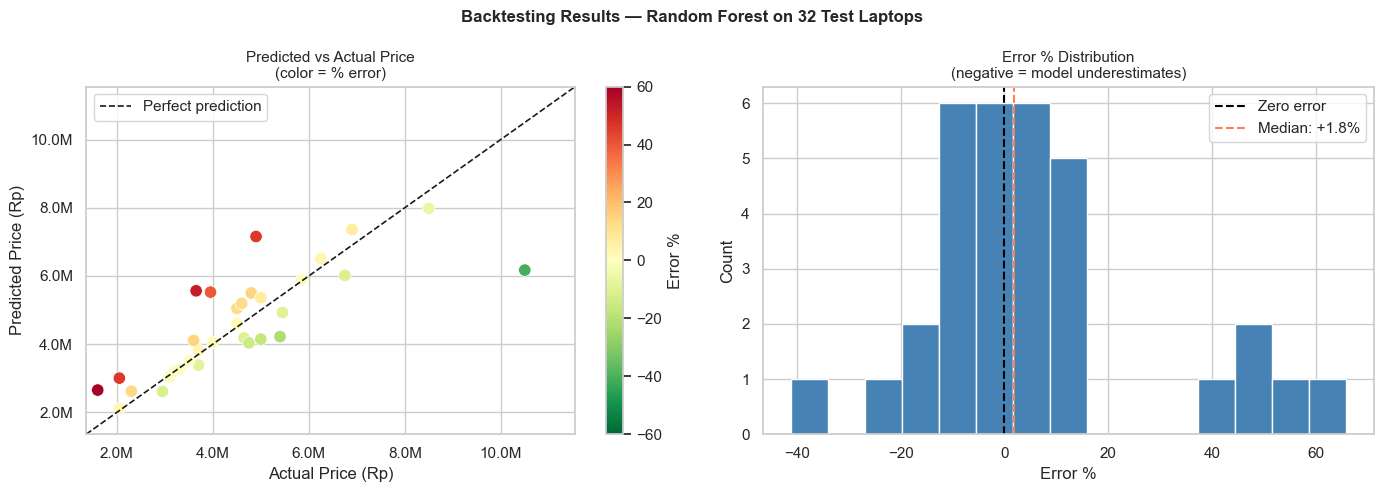


Note: A negative error means the model predicted LOWER than the actual listing price.
      A positive error means the model predicted HIGHER than the actual listing price.
      Median error: +1.8% — model slightly overestimates


In [30]:

# Scatter plot: predicted vs actual with error color coding
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter with error % as color
sc = axes[0].scatter(
    backtest_df['actual_price'], backtest_df['predicted_price'],
    c=backtest_df['error_pct'], cmap='RdYlGn_r', vmin=-60, vmax=60,
    s=80, edgecolors='white', linewidth=0.5
)
lims = [backtest_df['actual_price'].min() * 0.85, backtest_df['actual_price'].max() * 1.1]
axes[0].plot(lims, lims, 'k--', linewidth=1.2, label='Perfect prediction')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_title('Predicted vs Actual Price\n(color = % error)', fontsize=11)
axes[0].set_xlabel('Actual Price (Rp)')
axes[0].set_ylabel('Predicted Price (Rp)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].legend()
plt.colorbar(sc, ax=axes[0], label='Error %')

# Right: error % distribution
axes[1].hist(backtest_df['error_pct'], bins=15, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--', label='Zero error')
axes[1].axvline(backtest_df['error_pct'].median(), color='coral', linewidth=1.5,
                linestyle='--', label=f'Median: {backtest_df["error_pct"].median():+.1f}%')
axes[1].set_title('Error % Distribution\n(negative = model underestimates)', fontsize=11)
axes[1].set_xlabel('Error %')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Backtesting Results — Random Forest on 32 Test Laptops', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nNote: A negative error means the model predicted LOWER than the actual listing price.')
print(f'      A positive error means the model predicted HIGHER than the actual listing price.')
print(f'      Median error: {backtest_df["error_pct"].median():+.1f}% — {"model slightly underestimates" if backtest_df["error_pct"].median() < 0 else "model slightly overestimates"}')
